# Truncated QAOA Circuits via QAP Mapping

This notebook demonstrates how to build and optimize **truncated QAOA circuits** using the Quadratic Assignment Problem (QAP) mapping. Given a Weighted MaxCut Hamiltonian on a 12-node graph, we find the qubit ordering that places the highest-weight interactions within SWAP distance *k*, producing a family of truncated Hamiltonians of increasing completeness. A depth-one QAOA is then trained on each truncated circuit while the energy is evaluated against the **original Hamiltonian**, showing that circuits with far fewer two-qubit gates can still recover the optimal solution.

In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import quadratic_assignment as qap

import rustworkx as rx
from rustworkx.visualization import mpl_draw


from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import (
    QAOAAnsatz,
    CXGate,
)
from qiskit.circuit.library.standard_gates.equivalence_library import _sel
from qiskit.quantum_info import SparsePauliOp

from qiskit_aer import AerSimulator

from qiskit.transpiler import (
    CouplingMap,
    Layout,
    PassManager,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import (
    BasisTranslator,
    HighLevelSynthesis,
    InverseCancellation,
    UnrollCustomDefinitions,
)
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy

from qopt_best_practices.transpilation.annotated_transpilation_passes import (
    AnnotatedPrepareCostLayer,
    AnnotatedCommuting2qGateRouter,
    AnnotatedSwapToFinalMapping,
    UnrollBoxes,
)

from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import Sampler

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.solvers import CplexSolver

from qaoa_training_pipeline.utils.graph_utils import graph_to_operator
from qaoa_training_pipeline.evaluation import EfficientDepthOneEvaluator
from qaoa_training_pipeline.training import  DepthOneScanTrainer


from qopt_best_practices.transpilation.cost_layer import get_cost_layer
from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping
from qopt_best_practices.transpilation.qaoa_construction_pass import QAOAConstructionPass
from qiskit_optimization.translators import from_ising


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


We use a 12-node Weighted MaxCut instance loaded from `data/graph_12nodes.json`. The graph is converted to an Ising Hamiltonian via Qiskit Optimization's `Maxcut` class, which serves as the target cost operator throughout the notebook.

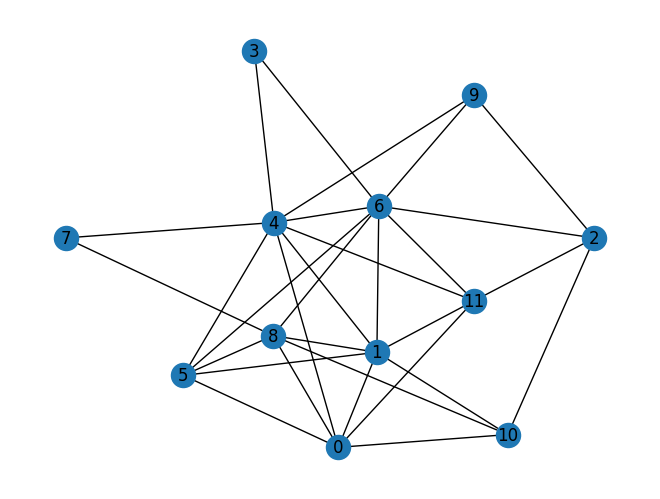

In [2]:
filename = "data/graph_12nodes.json"

with open(filename, 'r') as f:
    graph_data = json.load(f)

num_nodes = graph_data['num_nodes']
edges = graph_data['edges']

graph = rx.PyGraph()
graph.add_nodes_from([None] *  num_nodes)
graph.add_edges_from([tuple(edge) for edge in edges])
mc = Maxcut(graph)
mc.draw()


We solve the problem classically with CPLEX to obtain a reference solution. This optimal bitstring is used throughout as the benchmark for evaluating the truncated QAOA results.

Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_10 - 2*x_0*x_11 - 2*x_0*x_4 - 2*x_0*x_5 - 2*x_0*x_8
  - 2*x_1*x_10 - 2*x_1*x_11 - 2*x_1*x_4 - 2*x_1*x_5 - 2*x_1*x_6 - 2*x_1*x_8
  - 2*x_2*x_10 - 2*x_2*x_11 - 2*x_2*x_6 - 2*x_2*x_9 - 2*x_3*x_4 - 2*x_3*x_6
  - 2*x_4*x_11 - 2*x_4*x_5 - 2*x_4*x_6 - 2*x_4*x_7 - 2*x_4*x_9 - 2*x_5*x_6
  - 2*x_5*x_8 - 2*x_6*x_11 - 2*x_6*x_8 - 2*x_6*x_9 - 2*x_7*x_8 - 2*x_8*x_10
  + 6*x_0 + 7*x_1 + 4*x_10 + 5*x_11 + 4*x_2 + 2*x_3 + 8*x_4 + 5*x_5 + 8*x_6
  + 2*x_7 + 6*x_8 + 3*x_9

Subject to
  No constraints

  Binary variables (12)
    x_0 x_1 x_2 x_3 x_4 x_5 x_6 x_7 x_8 x_9 x_10 x_11

[1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0.]


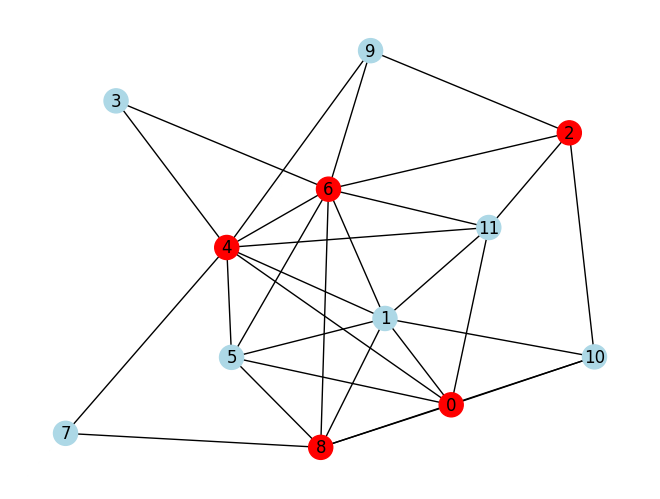

In [3]:
opt_problem = mc.to_optimization_problem()
print(opt_problem.prettyprint())
ham,_ = opt_problem.to_ising()

validation_solver = CplexSolver()

result = validation_solver.solve(opt_problem )
print(result.x)

node_colors = []
for node in range(num_nodes):
    if result.x[node] == 1:
        node_colors.append("red")
    else:
        node_colors.append("lightblue")

pos = rx.spring_layout(graph, seed=42)


classical_solution = "".join(
    str(int(bit))
    for bit in result.x
)


mpl_draw(graph, node_color=node_colors, with_labels=True,pos=pos)
plt.show()

Two utilities used when compiling truncated circuits:

- `pass_manager_truncated`: two-stage transpiler that first routes the QAOA cost layer through the SWAP strategy and decomposes it to RZ/RZZ gates, then translates to the backend's native gate set (CZ, SX, X, RZ).
- `_count_two_qubit_terms`: counts the number of ZZ interactions in a Hamiltonian, used to compute the edge-retention percentage for each truncation level.

In [4]:
def pass_manager_truncated(backend, opt_level, initial_layout, seed, swap_strat, edge_coloring, p_layers=1):
    staged_pm = generate_preset_pass_manager(opt_level, backend, initial_layout=initial_layout, seed_transpiler=seed)

    staged_pm.pre_init = PassManager([AnnotatedPrepareCostLayer(), 
                                      AnnotatedCommuting2qGateRouter(swap_strat), AnnotatedSwapToFinalMapping(),
                                    UnrollBoxes(),       HighLevelSynthesis(basis_gates=["x", "cx", "sx", "rz", "id"]),
        InverseCancellation(gates_to_cancel=[CXGate()]),])

    staged_pm.init     = PassManager([QAOAConstructionPass(num_layers=p_layers)])
    staged_pm.post_init = PassManager([
        UnrollCustomDefinitions(_sel, basis_gates=backend.operation_names),
        BasisTranslator(_sel, target_basis=backend.operation_names),
    ])
    return staged_pm

def _count_two_qubit_terms(op):
    return sum(
        1 for p in op.paulis
        if sum(str(c) != "I" for c in list(p)) == 2
    )

Two functions implement the truncation pipeline:

- `get_variational_qc(k, ham)`: for a given SWAP distance *k*, uses QAP to find the qubit permutation that concentrates the highest-weight edges within distance *k*, builds the truncated Hamiltonian `Hc_k` from those edges, and compiles the circuit via `pass_manager_truncated`.
- `build_truncated_hamiltonians(ham)`: sweeps a geometrically-spaced range of *k* values and records, for each level, the truncated Hamiltonian, its circuit, and circuit metrics (depth, two-qubit depth, CZ count, and percentage of original edges retained).

In [5]:
def get_variational_qc(k, ham, importance_mode="abs", seed=0):
    Q  = from_ising(ham, offset=0).objective.quadratic.to_array()
    n  = Q.shape[0]

    backend = GenericBackendV2(
        num_qubits=n,
        coupling_map=CouplingMap.from_line(n),
        basis_gates=["cz", "id", "rz", "sx", "x"],
        seed=seed,
    )
    swap_strat   = SwapStrategy.from_line(range(n))
    edge_coloring = {(i, i + 1): (i + 1) % 2 for i in range(n - 1)}
    edge_coloring.update({(b, a): c for (a, b), c in edge_coloring.items()})

    weight = np.abs(Q) if importance_mode == "abs" else Q ** 2
    mask   = (swap_strat.distance_matrix <= k).astype(int)
    perm   = qap(-weight, mask).col_ind

    qubo_mapped = weight * mask[perm][:, perm]
    np.fill_diagonal(qubo_mapped, 0)

    doubles      = graph_to_operator(nx.from_numpy_array(qubo_mapped))
    doubles_cost = get_cost_layer(doubles)

    cost_layer = QuantumCircuit(n)
    cost_layer.append(doubles_cost, range(n))
    cost_layer    = transpile(cost_layer.decompose(), basis_gates=["sx", "x", "rz", "rzz"],optimization_level=3)
    initial_layout = Layout.from_intlist(perm, cost_layer.qregs[0])



    ansatz = pass_manager_truncated(backend, 3, initial_layout, seed, swap_strat, edge_coloring).run(cost_layer)
    ansatz.remove_final_measurements()

    Hc_k = SparsePauliOp(doubles.paulis, doubles.coeffs)
    return ansatz, Hc_k, cost_layer


def build_truncated_hamiltonians(ham, importance_mode="abs", seed=0, n_k_points=25):
    n    = from_ising(ham, offset=0).objective.quadratic.to_array().shape[0]
    #norm = ham / max(abs(ham.coeffs))

    k_list = np.unique(np.concatenate((
        [0],
        np.round(np.geomspace(1, n - 2, num=max(3, n_k_points - 1))).astype(int),
        [n - 2],
    )))

    results = {}
    or_edges = _count_two_qubit_terms(ham)

    for k in k_list:
        ansatz, Hc_k, qc = get_variational_qc(k, ham, importance_mode=importance_mode, seed=seed)
        results[k] = {
            "hamiltonian": Hc_k,
            "circuit":     qc,
            "metrics": {
                "depth":          ansatz.depth(),
                "two_q_depth":    ansatz.depth(lambda g: g.operation.num_qubits == 2),
                "cz_count":       ansatz.count_ops().get("cz", 0),
                "edge_percentage": 100 * _count_two_qubit_terms(Hc_k) / or_edges if or_edges else 0.0,
            },
        }

    return results


truncated_info = build_truncated_hamiltonians(ham, importance_mode="abs", seed=0, n_k_points=25)

for k, data in truncated_info.items():
    print(f"k={k}: {data['metrics']}")

/opt/homebrew/Caskroom/miniforge/base/envs/optimization/lib/python3.10/site-packages/qopt_best_practices/transpilation/qaoa_construction_pass.py:120: UserWarning: Layout not found, assigining trivial layout
  warnings.warn("Layout not found, assigining trivial layout")
/opt/homebrew/Caskroom/miniforge/base/envs/optimization/lib/python3.10/site-packages/qiskit/circuit/quantumcircuit.py:4704: UserWarning: Trying to add QuantumRegister to a QuantumCircuit having a layout
  circ.add_register(qreg)


k=0: {'depth': 32, 'two_q_depth': 6, 'cz_count': 16, 'edge_percentage': 26.666666666666668}
k=1: {'depth': 59, 'two_q_depth': 16, 'cz_count': 52, 'edge_percentage': 46.666666666666664}
k=2: {'depth': 89, 'two_q_depth': 26, 'cz_count': 70, 'edge_percentage': 56.666666666666664}
k=3: {'depth': 153, 'two_q_depth': 45, 'cz_count': 98, 'edge_percentage': 60.0}
k=4: {'depth': 123, 'two_q_depth': 41, 'cz_count': 114, 'edge_percentage': 70.0}
k=5: {'depth': 226, 'two_q_depth': 77, 'cz_count': 148, 'edge_percentage': 66.66666666666667}
k=6: {'depth': 250, 'two_q_depth': 80, 'cz_count': 199, 'edge_percentage': 93.33333333333333}
k=7: {'depth': 290, 'two_q_depth': 96, 'cz_count': 192, 'edge_percentage': 96.66666666666667}
k=8: {'depth': 262, 'two_q_depth': 86, 'cz_count': 195, 'edge_percentage': 96.66666666666667}
k=9: {'depth': 366, 'two_q_depth': 121, 'cz_count': 248, 'edge_percentage': 100.0}
k=10: {'depth': 330, 'two_q_depth': 110, 'cz_count': 230, 'edge_percentage': 100.0}


We select truncation level `k=4`, which retains 70 % of the original edges while cutting circuit depth roughly in half. The interaction graph below uses the same node positions as the original graph, making it easy to see which edges were kept.

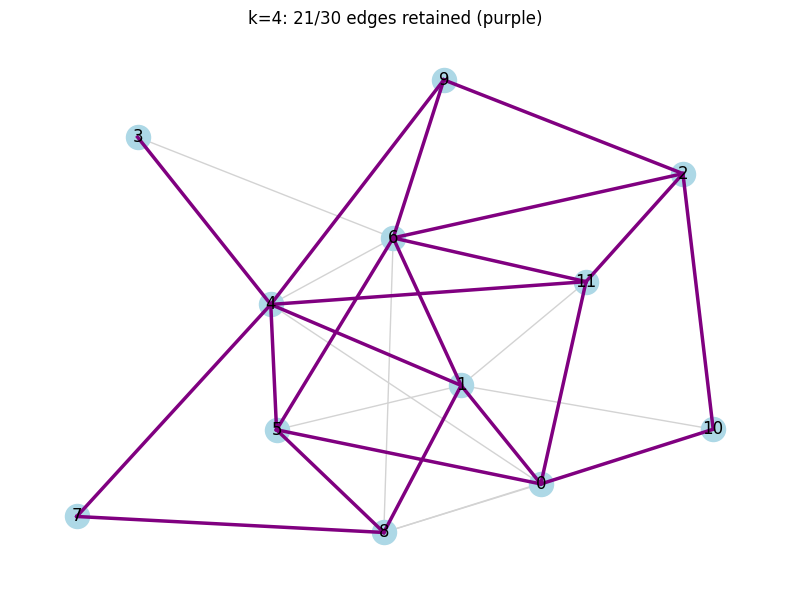

In [6]:
k_layer = 4

ham_truncated = truncated_info[k_layer]["hamiltonian"]
qc_truncated = truncated_info[k_layer]["circuit"]

# Build set of edges retained by the truncated Hamiltonian
truncated_edge_set = set()
for pauli, coeff in zip(ham_truncated.paulis, ham_truncated.coeffs):
    pauli_label = pauli.to_label()[::-1]
    active_qubits = [q for q, op in enumerate(pauli_label) if op == "Z"]
    if len(active_qubits) == 2:
        u, v = active_qubits
        truncated_edge_set.add((min(u, v), max(u, v)))

fig, ax = plt.subplots(figsize=(8, 6))

# Draw full original graph with dropped edges in light grey
mpl_draw(graph, pos=pos, with_labels=True, edge_color="lightgrey",
         node_color="lightblue", ax=ax)

# Overlay retained (truncated) edges in purple
for u, v in truncated_edge_set:
    ax.plot(
        [pos[u][0], pos[v][0]],
        [pos[u][1], pos[v][1]],
        color="purple", linewidth=2.5, zorder=2,
    )

n_kept = len(truncated_edge_set)
n_total = graph.num_edges()
ax.set_title(f"k={k_layer}: {n_kept}/{n_total} edges retained (purple)")
plt.tight_layout()
plt.show()

The circuit below shows the truncated cost layer for `k=4` in the RZZ/RZ basis, before hardware compilation. Each RZZ block corresponds to one retained edge; the QAP permutation ensures all of them fit within SWAP distance *k* on the linear topology.

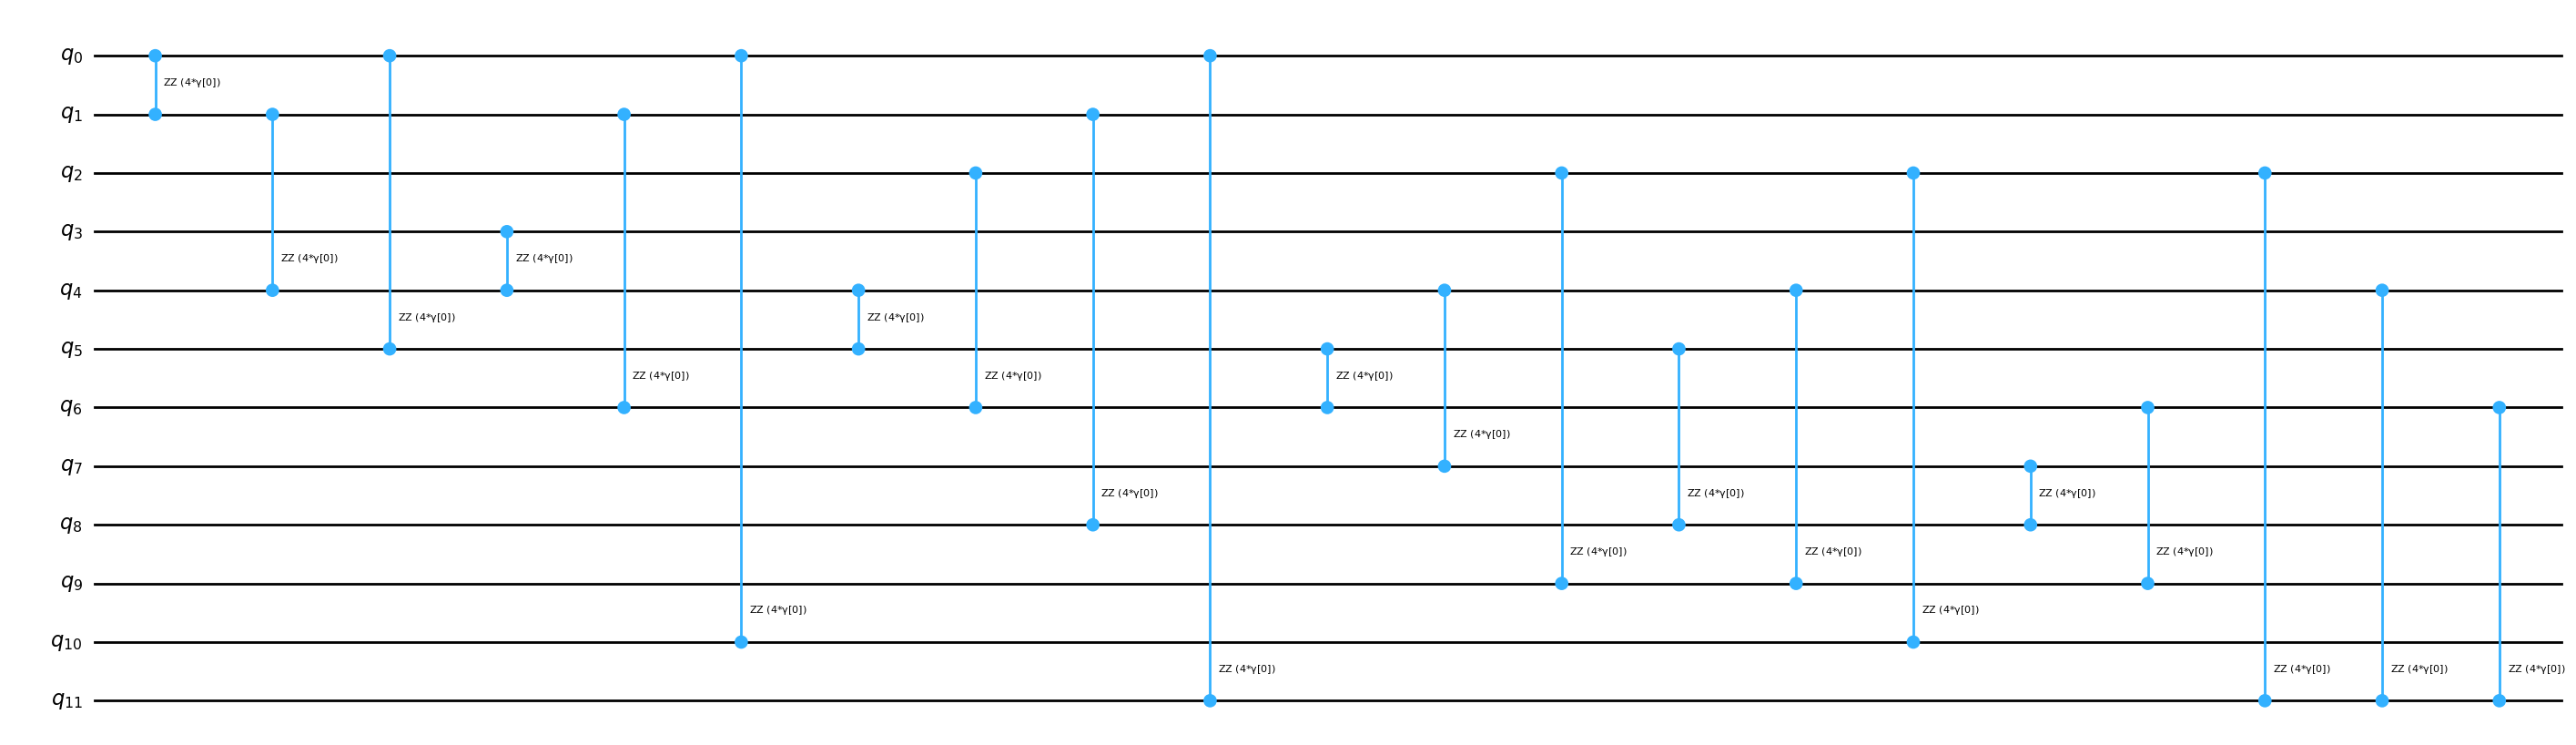

In [7]:
qc_truncated.draw('mpl', fold=-1)

Helper that returns the top-*n* bitstrings sorted by measurement count.

In [8]:
def get_top_n_results(data: dict, n: int = 10) -> dict:
    sorted_data = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))
    return dict(list(sorted_data.items())[:n])

We run both the truncated and the full QAOA circuit with the same training setup and compare their results side-by-side. The top row shows the truncated circuit results; the bottom row shows the full circuit. Matching solutions are highlighted in purple.

Truncated: ParamResult(data={'system_info': {'python_version': '3.10.18', 'system': 'Darwin', 'processor': 'arm', 'platform': 'macOS-15.7.3-arm64-arm-64bit', 'qaoa_training_pipeline_version': 33}, 'optimized_params': [2.8108986900540254, 3.306939635357677], 'optimized_qaoa_angles': [2.8108986900540254, 3.306939635357677], 'train_duration': 0.9399681091308594, 'energy': -2.7048351826366748, 'trainer': {'trainer_name': 'DepthOneScanTrainer', 'evaluator': {'name': 'EfficientDepthOneEvaluator'}, 'qaoa_angles_function': {'function_name': 'IdentityFunction'}}, 'num_points': 20, 'parameter_ranges': [(0.0, 3.141592653589793), (0.0, 6.283185307179586)], 'energy_history': [0.0, -5.551115123125783e-17, 0.0, 1.6653345369377348e-16, -8.326672684688674e-17, -6.38378239159465e-16, 0.0, 1.1102230246251565e-16, 1.3877787807814457e-16, 1.6653345369377348e-16, 0.0, 1.3877787807814457e-16, 1.3877787807814457e-16, -1.3877787807814457e-16, -3.0531133177191805e-16, -2.220446049250313e-16, 0.0, 2.220446049250

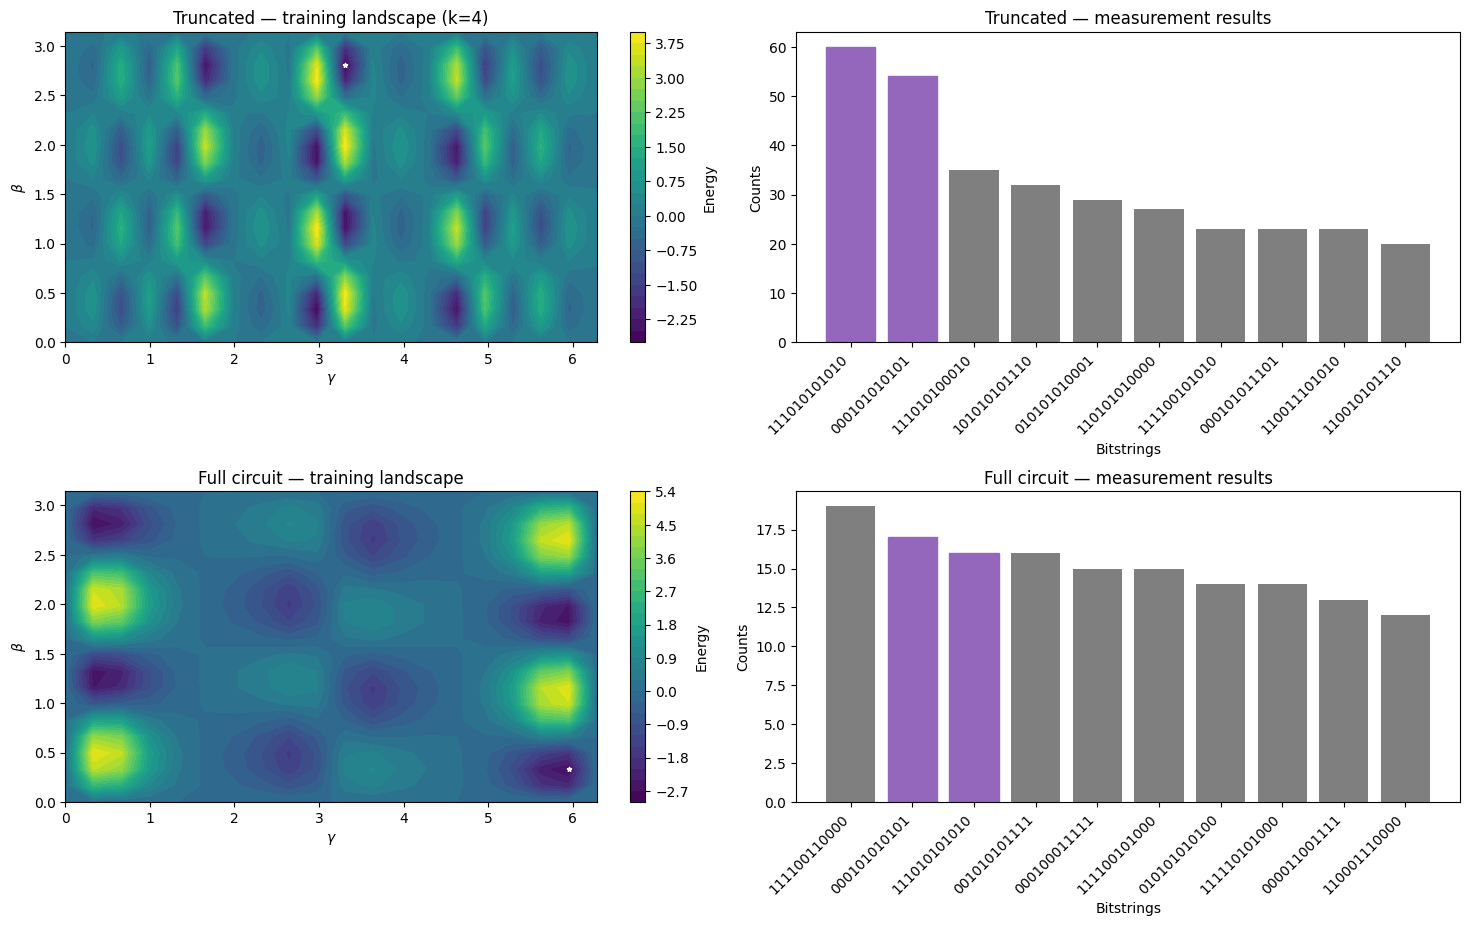

In [9]:
import io

# --- Truncated circuit ---
trainer_trunc = DepthOneScanTrainer(EfficientDepthOneEvaluator(), energy_minimization=True)
training_result_trunc = trainer_trunc.train(cost_op=ham, ansatz_circuit=qc_truncated, num_points=20)
print("Truncated:", training_result_trunc)

optimized_trunc = QAOAAnsatz(qc_truncated).decompose()
optimized_trunc.assign_parameters(training_result_trunc["optimized_params"], inplace=True)
optimized_trunc.measure_all()

job_trunc = Sampler(mode=AerSimulator()).run(
    [transpile(optimized_trunc, basis_gates=["sx", "x", "rzz", "rz"])], shots=2**12
)
top_trunc = get_top_n_results(job_trunc.result()[0].data.meas.get_counts())

solutions_trunc = []
print("\nTruncated — matching solutions:")
for idx, (bitstring, count) in enumerate(top_trunc.items()):
    rev = bitstring[::-1]
    if classical_solution == rev or ''.join('1' if c == '0' else '0' for c in classical_solution) == rev:
        print(f"  {rev} | Counts: {count}")
        solutions_trunc.append(idx)

# --- Full circuit ---
trainer_full = DepthOneScanTrainer(EfficientDepthOneEvaluator(), energy_minimization=True)
training_result_full = trainer_full.train(ham, num_points=20)
print("\nFull:", training_result_full)

optimized_full = QAOAAnsatz(ham).decompose()
optimized_full.assign_parameters(training_result_full["optimized_params"], inplace=True)
optimized_full.measure_all()

job_full = Sampler(mode=AerSimulator()).run(
    [transpile(optimized_full, basis_gates=["sx", "x", "rzz", "rz"])], shots=2**12
)
top_full = get_top_n_results(job_full.result()[0].data.meas.get_counts())

solutions_full = []
print("\nFull — matching solutions:")
for idx, (bitstring, count) in enumerate(top_full.items()):
    rev = bitstring[::-1]
    if classical_solution == rev or ''.join('1' if c == '0' else '0' for c in classical_solution) == rev:
        print(f"  {rev} | Counts: {count}")
        solutions_full.append(idx)

# --- Combined figure ---
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.48, wspace=.10)

ax_trunc_land = fig.add_subplot(gs[0, 0])
ax_trunc_bar  = fig.add_subplot(gs[0, 1])
ax_full_land  = fig.add_subplot(gs[1, 0])
ax_full_bar   = fig.add_subplot(gs[1, 1])

# Row 0: truncated
trainer_trunc.plot(axis=ax_trunc_land, fig=fig)
ax_trunc_land.set_title(f"Truncated — training landscape (k={k_layer})")

ax_trunc_bar.bar(list(top_trunc.keys()), list(top_trunc.values()), color="tab:grey")
for sol in solutions_trunc:
    ax_trunc_bar.get_children()[sol].set_color("tab:purple")
ax_trunc_bar.set_ylabel("Counts")
ax_trunc_bar.set_xlabel("Bitstrings")
ax_trunc_bar.set_title("Truncated — measurement results")
plt.setp(ax_trunc_bar.get_xticklabels(), rotation=45, ha='right')

# Row 1: full circuit
trainer_full.plot(axis=ax_full_land, fig=fig)
ax_full_land.set_title("Full circuit — training landscape")

ax_full_bar.bar(list(top_full.keys()), list(top_full.values()), color="tab:grey")
for sol in solutions_full:
    ax_full_bar.get_children()[sol].set_color("tab:purple")
ax_full_bar.set_ylabel("Counts")
ax_full_bar.set_xlabel("Bitstrings")
ax_full_bar.set_title("Full circuit — measurement results")
plt.setp(ax_full_bar.get_xticklabels(), rotation=45, ha='right')
plt.show()